In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt



In [7]:
n_data = torch.ones(100,2)
x0 = torch.normal(2*n_data,1)
y0 = torch.zeros(100)
x1 = torch.normal(-2*n_data, 1)
y1 = torch.ones(100)
x = torch.cat((x0,x1), 0).type(torch.FloatTensor)
y = torch.cat((y0,y1), ).type(torch.LongTensor)
print(x)
print(y)

tensor([[ 0.8636,  2.4931],
        [ 2.0428,  4.4172],
        [ 2.4179, -0.2882],
        [ 2.4334,  1.6982],
        [ 0.9068,  1.2278],
        [ 1.9899,  2.5962],
        [ 1.1456,  2.8665],
        [ 2.3717,  1.9364],
        [ 3.3829,  0.1782],
        [ 0.8429,  2.6772],
        [ 2.2231,  2.3148],
        [-1.4597,  1.5329],
        [ 3.8723,  1.1570],
        [ 1.1249,  1.8124],
        [ 4.1960,  2.4751],
        [ 1.5558,  3.2082],
        [ 1.9151,  3.3942],
        [ 2.3847,  0.3601],
        [ 0.1952,  1.5404],
        [ 3.0945,  1.3143],
        [ 0.9344,  0.9672],
        [ 1.8883,  2.2309],
        [ 1.6923,  2.2405],
        [ 2.0933,  1.8988],
        [ 2.6179,  1.9995],
        [ 2.2090,  2.0602],
        [ 0.5593,  0.5507],
        [ 0.8656,  0.7554],
        [ 2.1477,  2.0852],
        [ 2.5738,  1.8220],
        [ 2.6210,  2.0176],
        [ 1.9541,  2.7213],
        [ 2.1623,  1.6756],
        [ 3.2608,  1.7402],
        [ 1.7194,  3.0375],
        [ 1.1614,  3

Net(
  (hidden): Linear(in_features=2, out_features=10, bias=True)
  (out): Linear(in_features=10, out_features=2, bias=True)
)
Sequential(
  (0): Linear(in_features=2, out_features=10, bias=True)
  (1): ReLU()
  (2): Linear(in_features=10, out_features=2, bias=True)
)


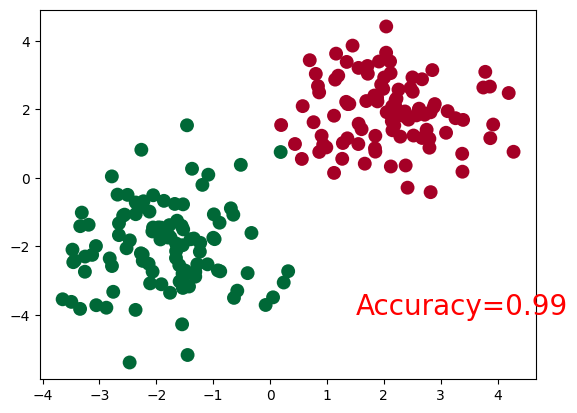

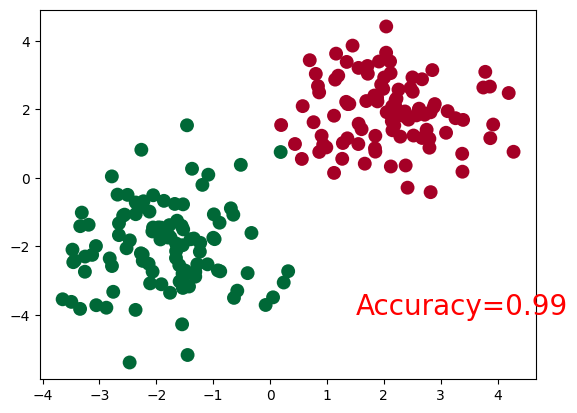

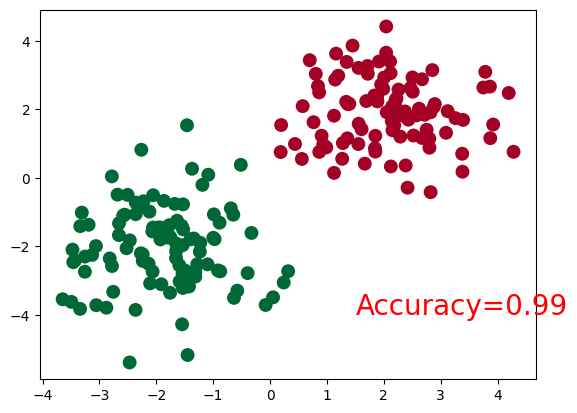

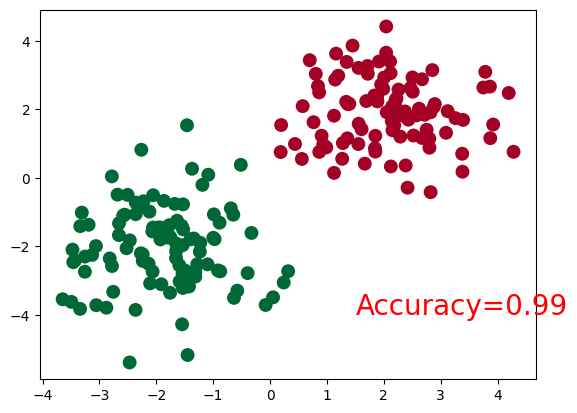

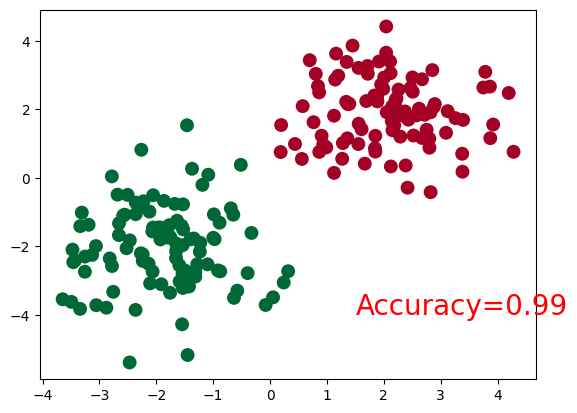

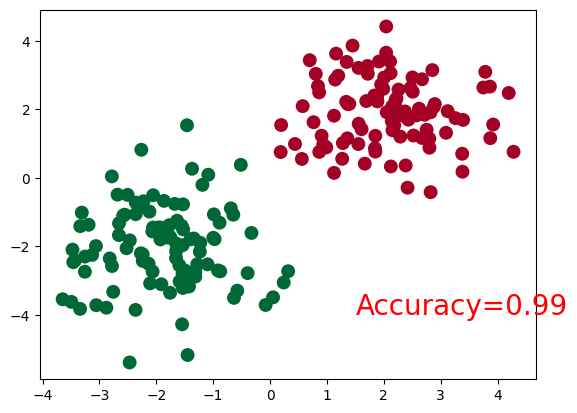

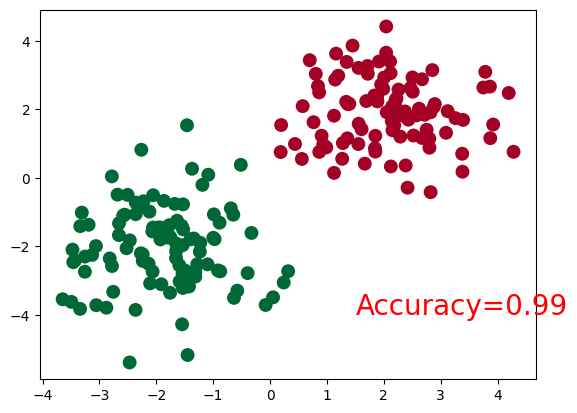

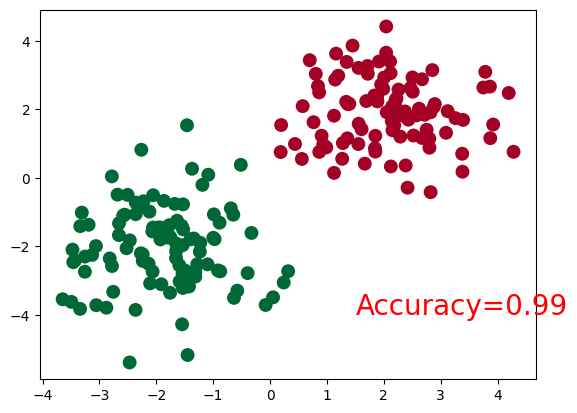

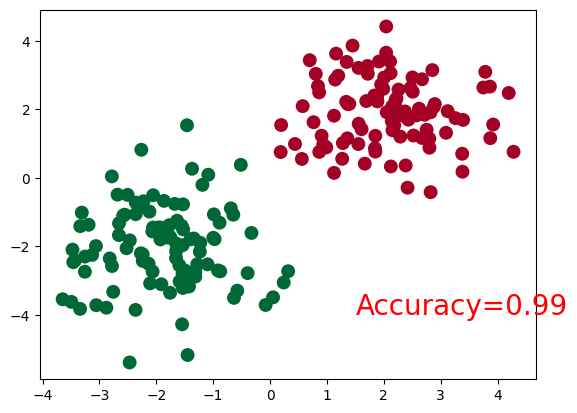

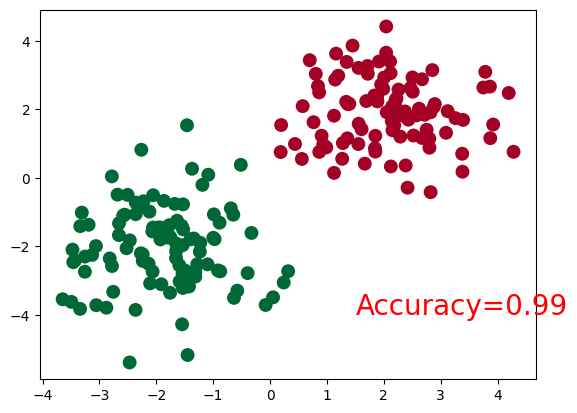

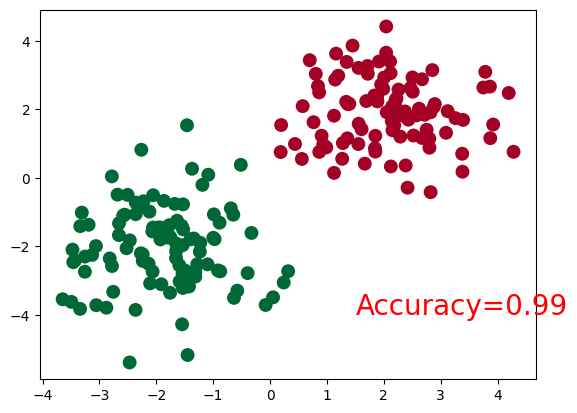

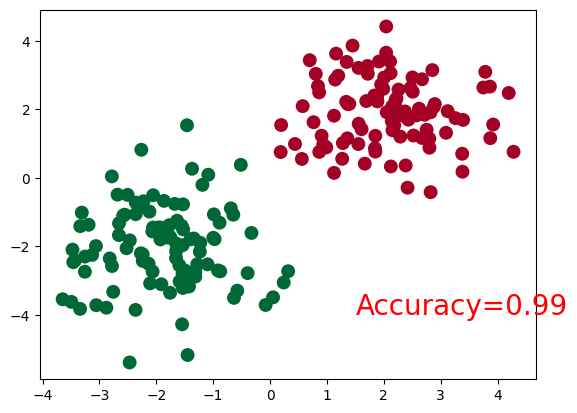

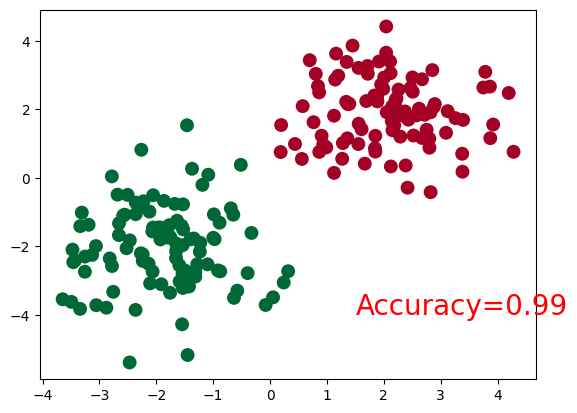

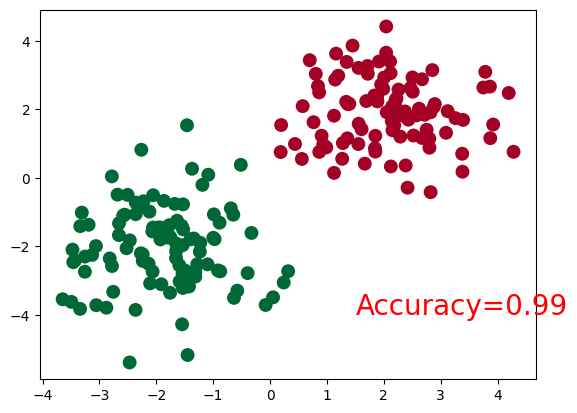

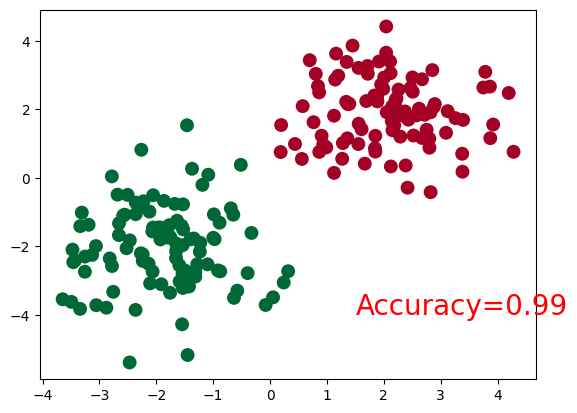

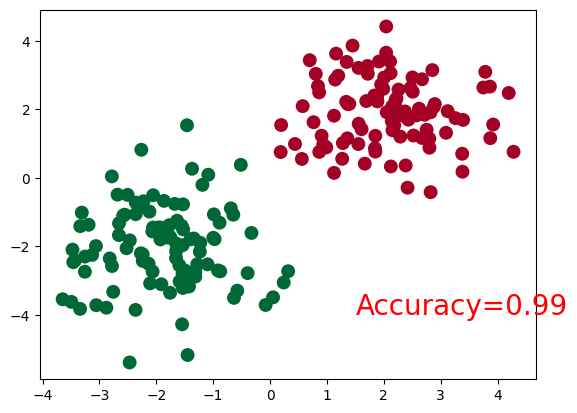

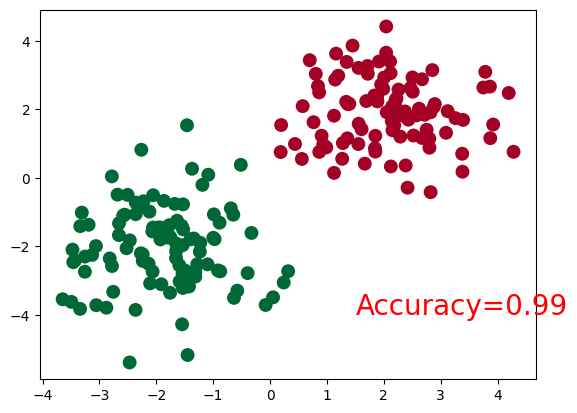

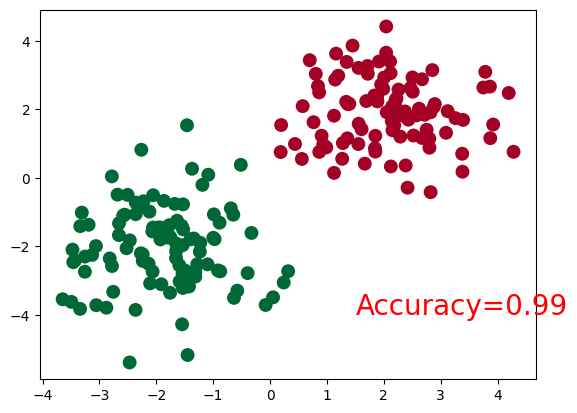

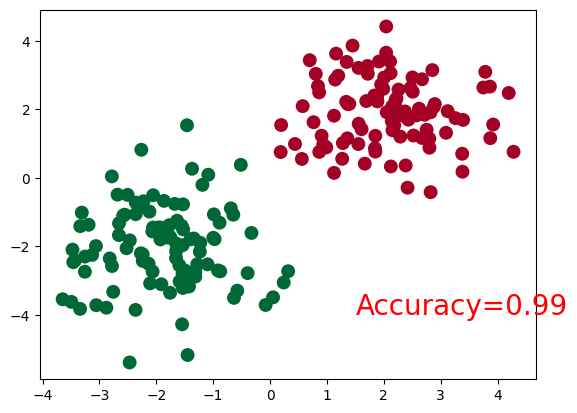

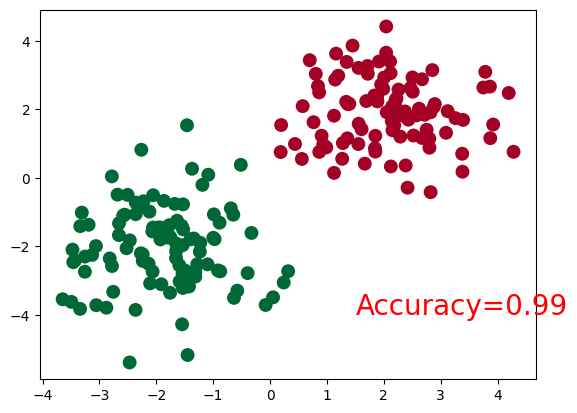

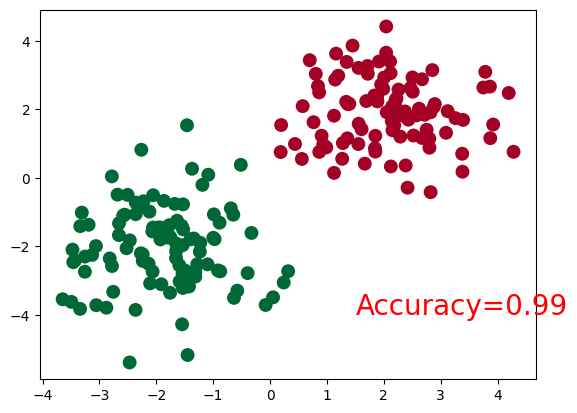

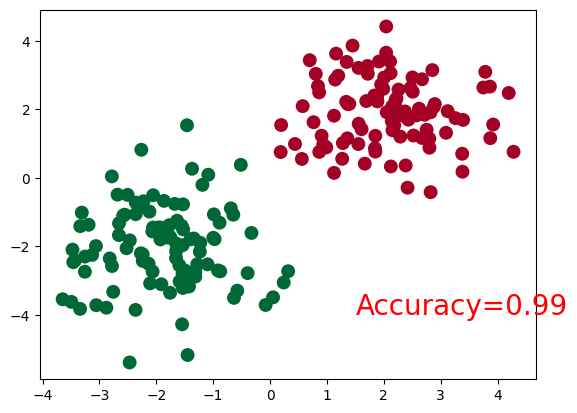

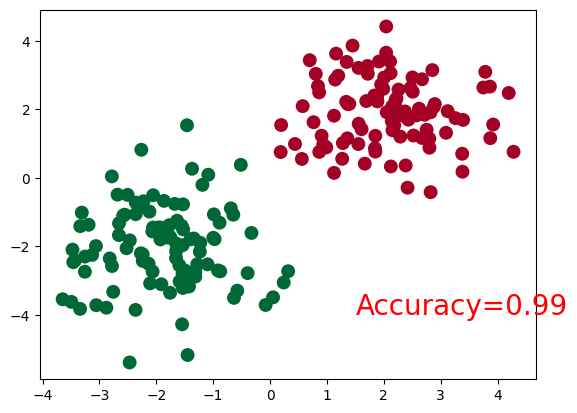

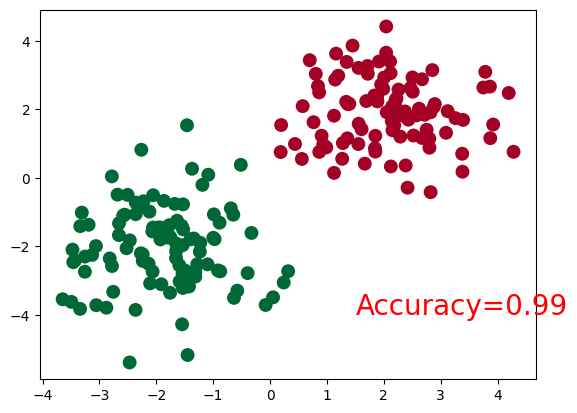

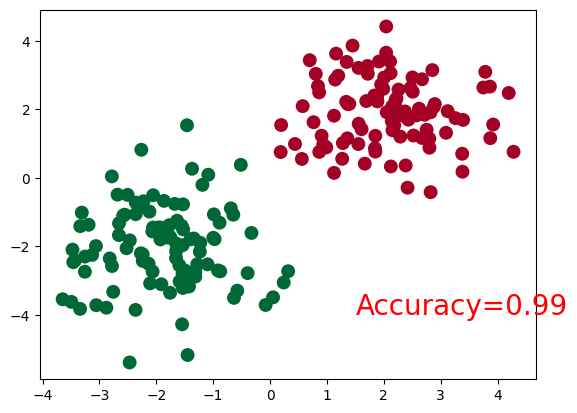

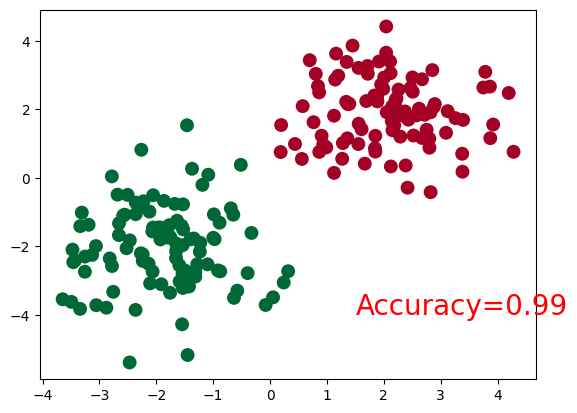

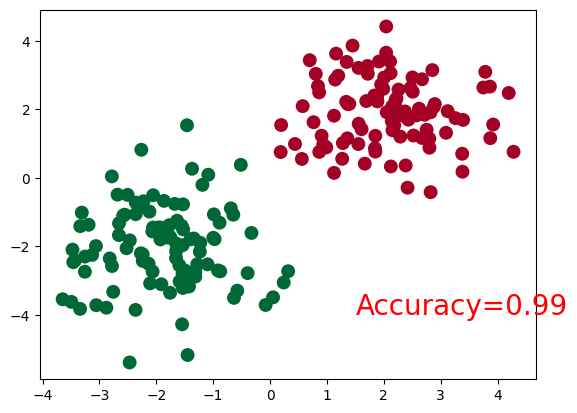

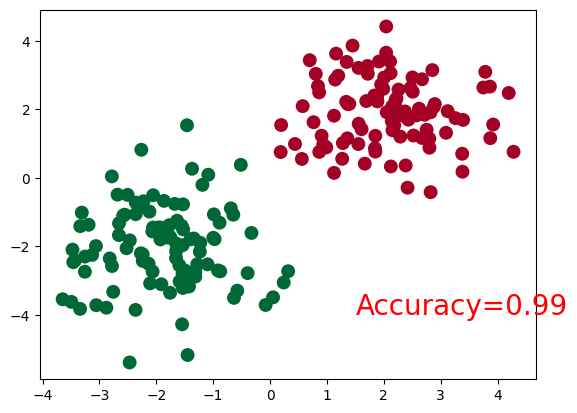

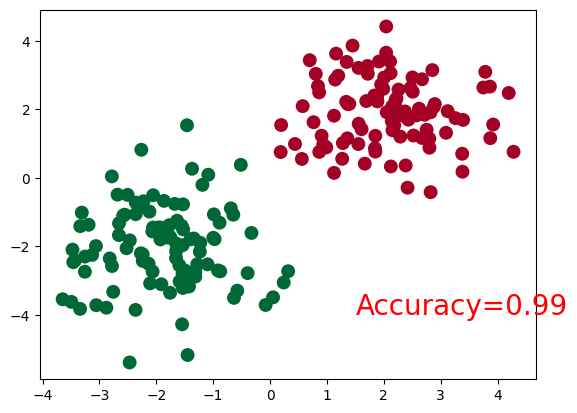

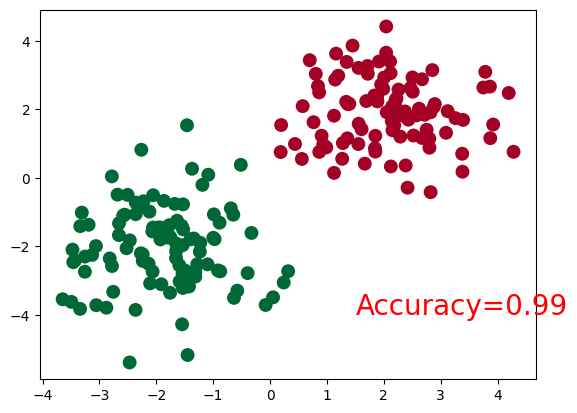

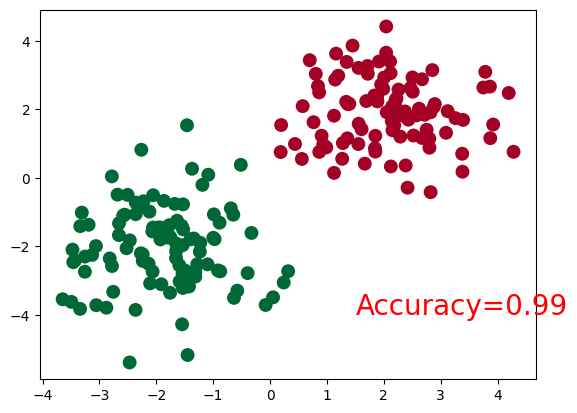

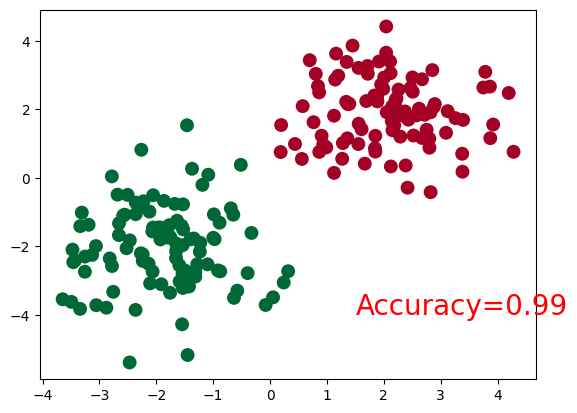

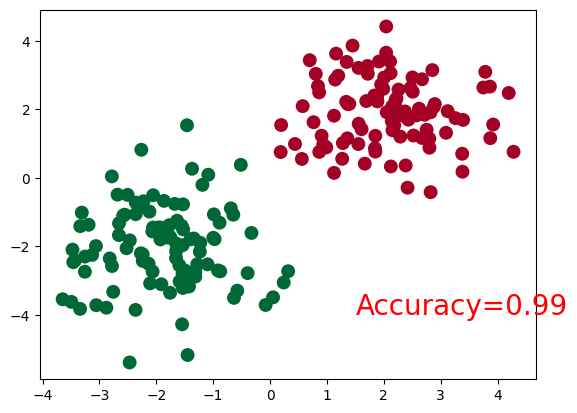

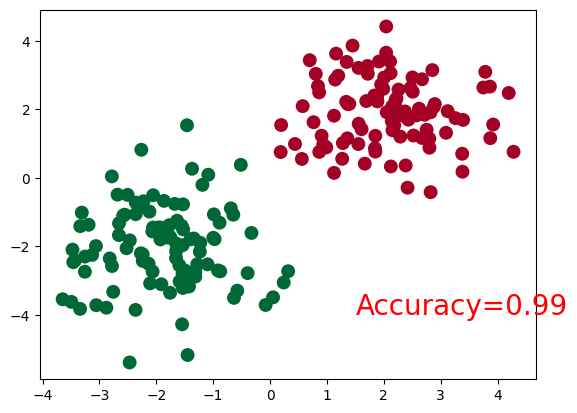

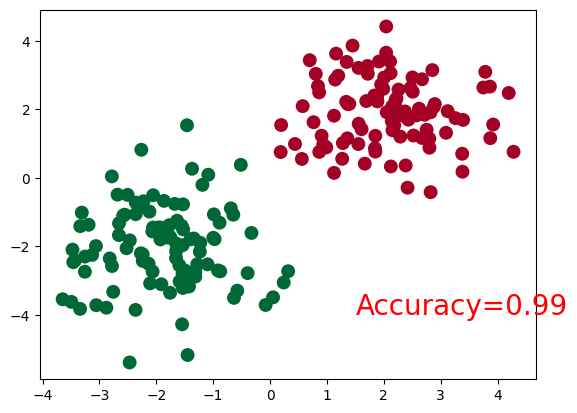

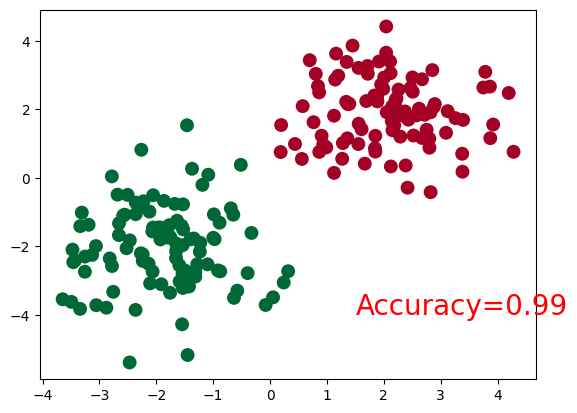

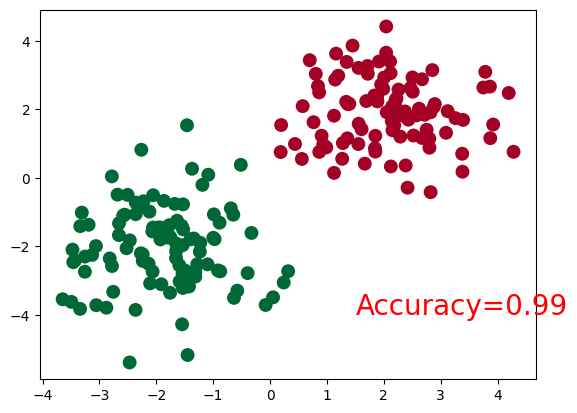

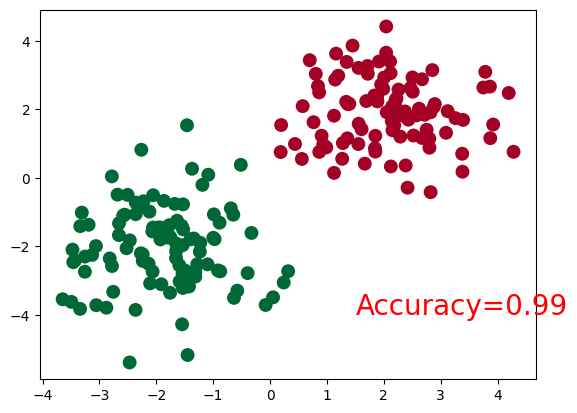

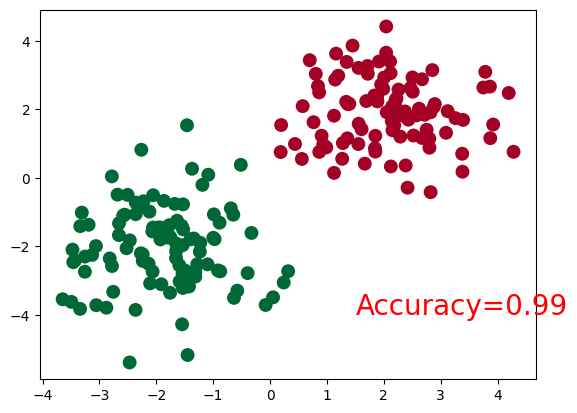

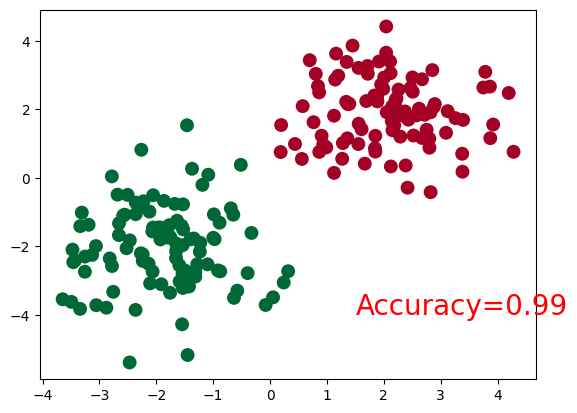

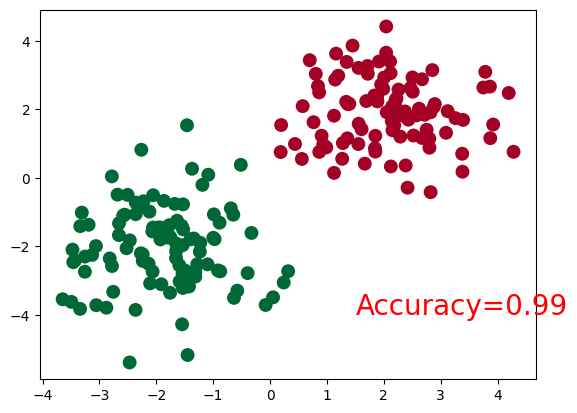

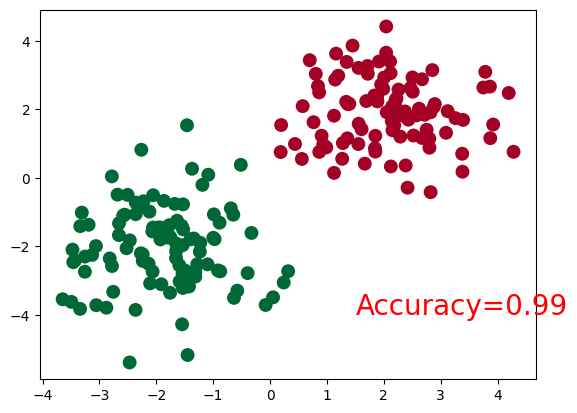

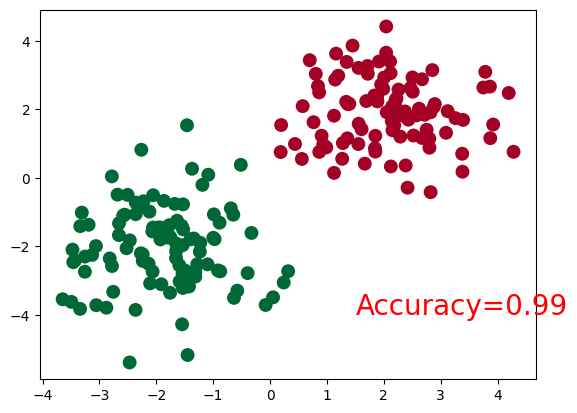

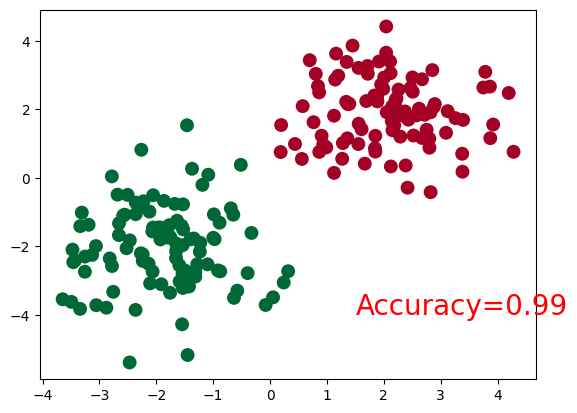

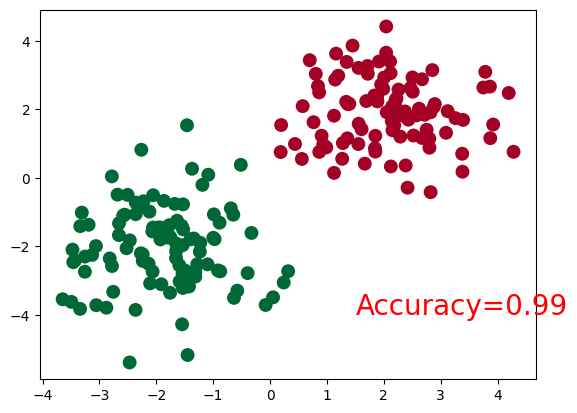

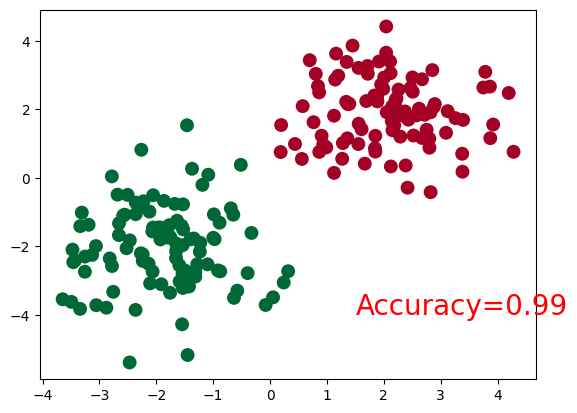

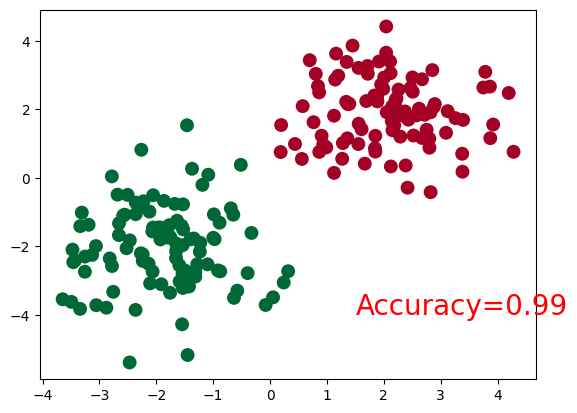

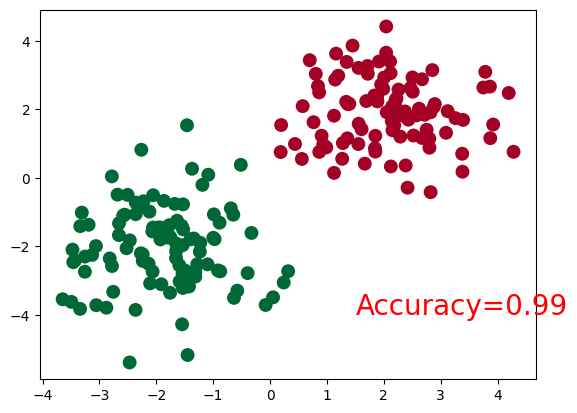

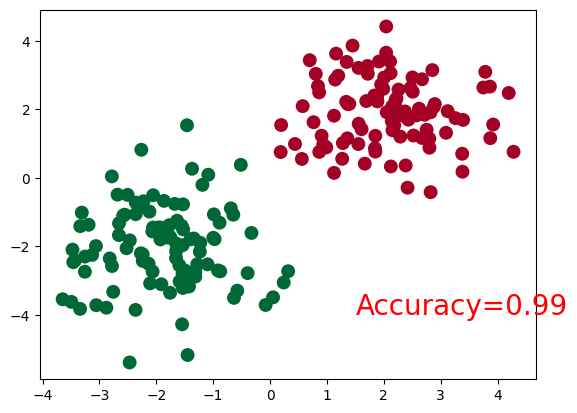

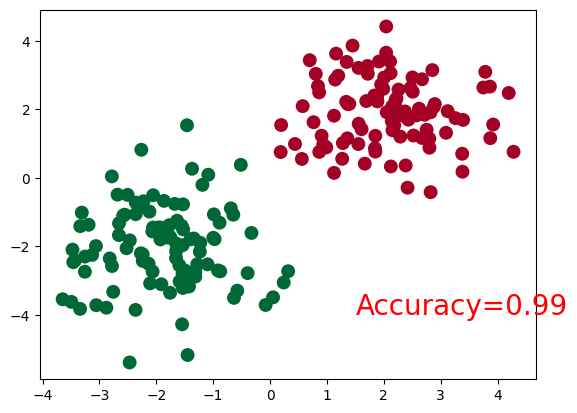

In [9]:
class Net(torch.nn.Module):
    def __init__(self, n_feature, n_hidden, n_output):
        super(Net, self).__init__()
        self.hidden = torch.nn.Linear(n_feature, n_hidden)   # hidden layer
        self.out = torch.nn.Linear(n_hidden, n_output)   # output layer

    def forward(self, x):
        x = F.relu(self.hidden(x))      # activation function for hidden layer
        x = self.out(x)
        return x

net1 = Net(n_feature=2, n_hidden=10, n_output=2)     # define the network
print(net1)  # net architecture
#alternative way to define a network
net2 = torch.nn.Sequential(
    torch.nn.Linear(2, 10),
    torch.nn.ReLU(),
    torch.nn.Linear(10, 2)
)
print(net2)

optimizer = torch.optim.SGD(net1.parameters(), lr=0.02)
loss_func = torch.nn.CrossEntropyLoss()  # the target label is NOT an one-hotted

plt.ion()   # something about plotting

for t in range(100):
    out = net1(x)                 # input x and predict based on x
    loss = loss_func(out, y)     # must be (1. nn output, 2. target), the target label is NOT one-hotted

    optimizer.zero_grad()   # clear gradients for next train
    loss.backward()         # backpropagation, compute gradients
    optimizer.step()        # apply gradients

    if t % 2 == 0:
        # plot and show learning process
        plt.cla()
        prediction = torch.max(out, 1)[1]
        pred_y = prediction.data.numpy()
        target_y = y.data.numpy()
        plt.scatter(x.data.numpy()[:, 0], x.data.numpy()[:, 1], c=pred_y, s=100, lw=0, cmap='RdYlGn')
        accuracy = float((pred_y == target_y).astype(int).sum()) / float(target_y.size)
        plt.text(1.5, -4, 'Accuracy=%.2f' % accuracy, fontdict={'size': 20, 'color':  'red'})
        plt.pause(0.1)

plt.ioff()
plt.show()